## Limpieza de los comentarios

In [ ]:
%run scripts\01_clean_data.py

# Usa: 
# - google-reviews-scraper-pro/reviews.db
# - url.csv

# Genera: 
# - data.csv

## Generación de score de sentimientos

In [ ]:
%run scripts\02_NLP_pysentimiento.py

# Usa: 
# - data.csv

# Genera: 
# - reviews_pysentimiento.csv

In [1]:
import pandas as pd

# -- Imputación de datos faltantes --

df_reviews = pd.read_csv(r'data/reviews_pysentimiento.csv')
df_reviews = df_reviews.dropna(subset='clean_review_text')

# distribución de emociones
print('Distribución de emociones:')
print(df_reviews['emocion'].value_counts())
print()

# ejemplos de cada emoción
print('Ejemplos por emoción:')
for emocion in df_reviews['emocion'].dropna().unique():
    ejemplo = df_reviews[df_reviews['emocion'] == emocion]['clean_review_text'].dropna().iloc[0]
    print(f'\n{emocion}: {ejemplo[:1000]}')

# -- Guarda datos --
df_reviews.to_csv('data/reviews_con_sentimiento.csv', index=False, encoding='utf-8-sig')
print('✅Datos guardados en: data/reviews_con_sentimiento.csv')


Distribución de emociones:
emocion
others      10764
anger        7302
joy          6339
sadness       174
surprise       22
fear           11
disgust         1
Name: count, dtype: int64

Ejemplos por emoción:

joy: EL MEJOR SERVICIO AL CLIENTE QUE HE IDO EL SISTEMA DE ATENCIÓN ES RÁPIDO EFICAZ Y PROFESIONAL

anger: MALA EXPERIENCIA EN RADIOLOGÍA SE NEGARON A ATENDERME POR QUE ESTABA MUY OCUPADO QUE REGRESARA OTRO DÍA

others: POR WHATSAPP SE ME HIZO IMPOSIBLE SACAR UNA CITA MEJOR MARQUEN DESE SU CEL

sadness: ES INCREÍBLE LO MODERNA Y GRANDE QUE ES ESA EMPRESA A NIVEL NACIONAL Y NO ACEPTE PAGOS CON TARJETA AMERICAN EXPRESS UNA COSA LAMENTABLE

surprise: NOT IMPRESSED!!! HAD OUR ANTIGEN TEST TODAY AND STILL WAITING FOR RESULTS FOR CANADIANS FLYING OUT TOMORROW? DOES ANYONE HAVE ANY SUGGESTIONS

fear: MUY CONFUSO Y SIN RESPUESTAS

disgust: JAMÁS VOLVERÍA ES EL PEOR LUGAR DEL TIPO EN EL QUE HE ESTADO!
✅Datos guardados en: data/reviews_con_sentimiento.csv


## Descriptivo global

In [ ]:
import matplotlib.font_manager as fm
import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords as nltk_stopwords

# Paleta azul-morado 
colores = ['#3d2fa8', '#6458cf', '#7f75f1', '#9992f7', '#918cec', '#9b95e8', '#bbb8f0']

# -- Stopwords --
stopwords_gramaticales = set([w.upper() for w in nltk_stopwords.words('spanish')])
stopwords_dominio = set([
    'SOLO', 'NADA', 'TIENEN', 'HACER', 'LES', 'NOS', 'HASTA',
    'SUCURSAL', 'GENTE', 'PERSONAS', 'LUGAR', 'VEZ', 'TE', 'MI',
    'DO', 'Q', 'ASÍ', 'VA', 'MA','AHÍ', 'NO', 'SÍ', 'SI', 'PUE', 'SER', 'TODA', 'AM', 'IR'
])
stopwords = stopwords_gramaticales | stopwords_dominio

# -- Variables para todas las gráficas --
FUENTE      = 'Open Sans'
FUENTE_PATH = fm.findfont(fm.FontProperties(family=FUENTE))
AZUL_OSCURO  = '#1a1a4e'
FONDO        = '#fbfbfd'

# -- Temas --
temas_cols = ['TIEMPO','SERVICIO','ESTUDIOS','CITAS','COSTOS','INSTALACIONES','OPTICA']
# colores para los 7 temas
colores_temas_neg = ['#e05c7a', '#7b2fa8', '#9b4dca', '#b06ee0', '#c490e8', '#d9b8f0', '#ede0f8']
colores_temas_pos = ['#2fa89e', '#2d4ea3', '#4a7fd4', '#6699e0', '#a8c4f0', '#c5d9f5', '#deeaff']


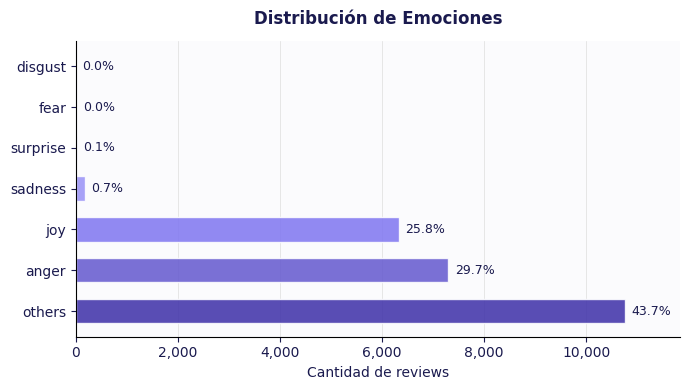

✅Datos guardados en: data/emociones.png


In [3]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker


counts = df_reviews['emocion'].value_counts()
total  = counts.sum()

fig, ax = plt.subplots(figsize=(7,4))

bars = ax.barh(counts.index, counts.values,
               color=colores[:len(counts)],
               edgecolor='white',
               height=0.6,
               alpha=0.85)          # tranparencia

# Grid
ax.set_axisbelow(True)
ax.grid(axis='x', color='#ddd', linewidth=0.5)

# Etiquetas de % al final de cada barra
for bar, val in zip(bars, counts.values):
    pct = val / total * 100
    ax.text(val + total * 0.005,                    # pequeño offset horizontal
            bar.get_y() + bar.get_height() / 2,
            f'{pct:.1f}%',
            va='center', fontsize=9, color=AZUL_OSCURO)

# Eje X con separador de miles 
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Límite extendido para que no se corten las etiquetas
ax.set_xlim(0, counts.max() * 1.1)

# Estilo general
ax.set_title('Distribución de Emociones', fontweight='bold', color=AZUL_OSCURO, pad=12)
ax.set_xlabel('Cantidad de reviews', color=AZUL_OSCURO)
ax.tick_params(colors=AZUL_OSCURO)
ax.set_facecolor(FONDO)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# -- Guarda datos --
plt.tight_layout()
plt.savefig('data/emociones.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅Datos guardados en: data/emociones.png')

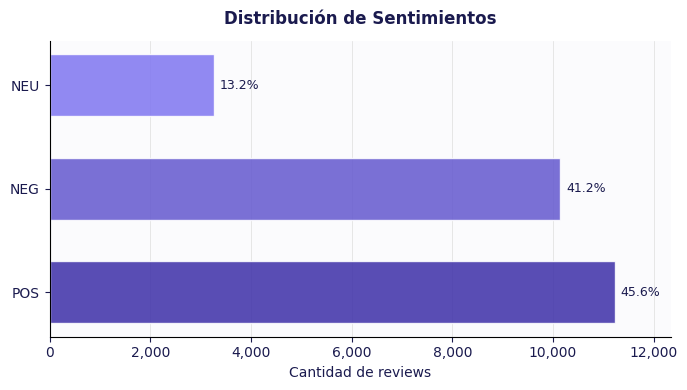

✅Datos guardados en: data/sentimientos.png


In [4]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

counts = df_reviews['sentimiento'].value_counts()
total  = counts.sum()

fig, ax = plt.subplots(figsize=(7,4))

bars = ax.barh(counts.index, counts.values,
               color=colores[:len(counts)],
               edgecolor='white',
               height=0.6,
               alpha=0.85)          # tranparencia

# Grid
ax.set_axisbelow(True)
ax.grid(axis='x', color='#ddd', linewidth=0.5)

# Etiquetas de % al final de cada barra
for bar, val in zip(bars, counts.values):
    pct = val / total * 100
    ax.text(val + total * 0.005,                    # pequeño offset horizontal
            bar.get_y() + bar.get_height() / 2,
            f'{pct:.1f}%',
            va='center', fontsize=9, color=AZUL_OSCURO)

# Eje X con separador de miles 
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Límite extendido para que no se corten las etiquetas
ax.set_xlim(0, counts.max() * 1.1)

# Estilo general
ax.set_title('Distribución de Sentimientos', fontweight='bold', color=AZUL_OSCURO, pad=12)
ax.set_xlabel('Cantidad de reviews', color=AZUL_OSCURO)
ax.tick_params(colors=AZUL_OSCURO)
ax.set_facecolor(FONDO)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# -- Guarda datos --
plt.tight_layout()
plt.savefig('data/sentimientos.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅Datos guardados en: data/sentimientos.png')

## Análisis de temas

### Palabras dominantes por sentimiento 

In [5]:
import pandas as pd
from collections import Counter
import re

# -- Carga datos --
df_reviews = pd.read_csv('data/reviews_con_sentimiento.csv', encoding='utf-8-sig')

# -- Conteo de paralabras por sentimiento --
def contar_palabras(df, sentimiento, etiqueta):
    df_filtrado = df[
        (df['sentimiento'] == sentimiento) &
        (df['clean_review_text'].notna())
    ]
    palabras = []
    for texto in df_filtrado['clean_review_text']:
        tokens = re.findall(r'\b[A-ZÁÉÍÓÚÑ]{3,}\b', str(texto))
        palabras.extend([p for p in tokens if p not in stopwords])
    
    conteo = Counter(palabras)
    print(f'\nTOP 30 palabras en reviews {etiqueta} ({len(df_filtrado)} reviews):')
    for palabra, freq in conteo.most_common(30):
        print(f'  {palabra}: {freq}')
    
    return conteo

# Nota: estas palabras se usan más adelante para generar temas de interés en 03_analisis_Temas.py
conteo_neg = contar_palabras(df_reviews, 'NEG', 'NEGATIVOS')
conteo_pos = contar_palabras(df_reviews, 'POS', 'POSITIVOS')



TOP 30 palabras en reviews NEGATIVOS (10133 reviews):
  SERVICIO: 4416
  CITA: 2802
  ATENCIÓN: 2447
  PÉSIMO: 2251
  MAL: 2096
  PERSONAL: 1671
  ESTUDIOS: 1571
  ULTRASONIDO: 1513
  LENTES: 1500
  TIEMPO: 1347
  HORA: 1317
  MALA: 1291
  BIEN: 1182
  ESTUDIO: 1166
  RESULTADOS: 1070
  HORAS: 962
  DÍA: 960
  HACEN: 897
  PERSONA: 869
  PÉSIMA: 820
  SALUD: 820
  ESPERANDO: 805
  ESPERAR: 791
  DICEN: 790
  DESPUÉS: 788
  LABORATORIO: 767
  DIJO: 756
  TRATO: 726
  DIJERON: 699
  DAN: 668

TOP 30 palabras en reviews POSITIVOS (11223 reviews):
  SERVICIO: 4291
  ATENCIÓN: 4092
  EXCELENTE: 3915
  PRECIOS: 2701
  BUENA: 2185
  BUEN: 2132
  ACCESIBLES: 1479
  PERSONAL: 1455
  RÁPIDO: 1245
  BIEN: 1229
  ESTUDIOS: 1051
  AMABLE: 976
  TRATO: 972
  AMABLES: 931
  LIMPIO: 801
  INSTALACIONES: 748
  RESULTADOS: 715
  BUENOS: 682
  CALIDAD: 666
  PRECIO: 646
  CITA: 583
  LABORATORIO: 574
  RÁPIDA: 525
  ATIENDEN: 500
  SUPER: 495
  EXELENTE: 487
  LENTES: 486
  RECOMIENDO: 472
  SALUD: 439


###  Nube de palabras

✅WordCloud guardado en data/wordcloud.png


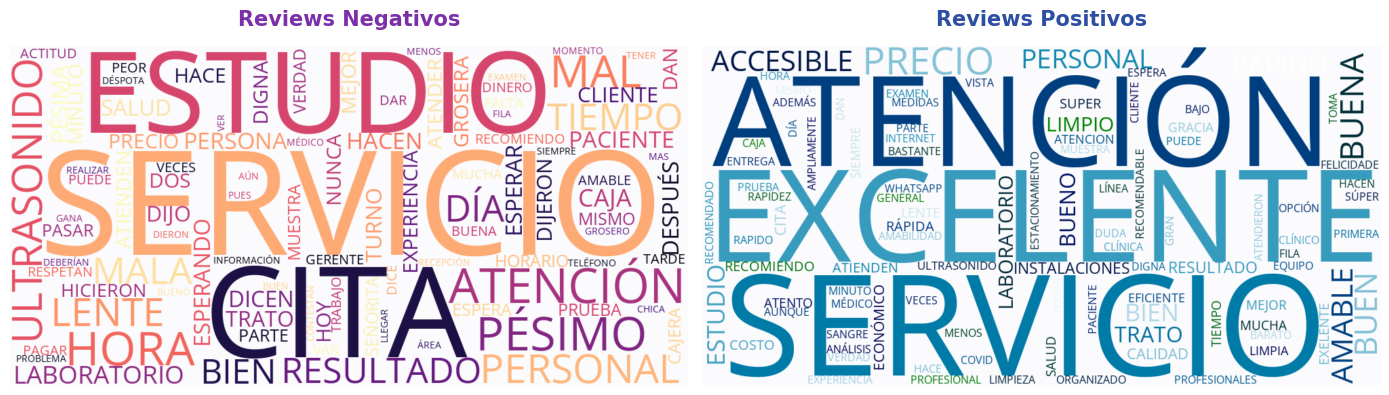

In [6]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# -- Textos --
texto_neg = ' '.join(df_reviews[
    (df_reviews['sentimiento'] == 'NEG') & 
    (df_reviews['clean_review_text'].notna())
]['clean_review_text'])

texto_pos = ' '.join(df_reviews[
    (df_reviews['sentimiento'] == 'POS') &
    (df_reviews['clean_review_text'].notna())
]['clean_review_text'])


# -- Configuración base --
wc_config = dict(
    font_path=FUENTE_PATH,
    width=1000, height=500,
    max_words=100,
    background_color=FONDO,
    stopwords=stopwords,
    collocations=False,
    prefer_horizontal=0.85,
)

fig, axes = plt.subplots(1, 2, figsize=(14, 8))
# fig.suptitle('Nube de Palabras — Reviews', 
#              fontsize=20, fontweight='bold', color=AZUL_OSCURO, y=1.02)

# -- WordCloud Negativos --
wc_neg = WordCloud(
    **wc_config,
    colormap='magma',
).generate(texto_neg)

axes[0].imshow(wc_neg, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('Reviews Negativos', fontsize=15, fontweight='bold', 
                   color='#7b2fa8', pad=15)

# -- WordCloud Positivos --
wc_pos = WordCloud(
    **wc_config,
    colormap='ocean',
).generate(texto_pos)

axes[1].imshow(wc_pos, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Reviews Positivos', fontsize=15, fontweight='bold',
                   color='#2d4ea3', pad=15)

# -- Guarda imagen --
plt.tight_layout()
plt.savefig('data/wordcloud.png', dpi=150, bbox_inches='tight')
print('✅WordCloud guardado en data/wordcloud.png')
plt.show()

### Temas dominantes por sentimiento 

In [7]:
%run scripts\03_analisis_Temas.py

# Usa: 
# - reviews_con_sentimiento.csv

# Genera: 
# - reviews_con_temas.csv

✅Datos guardados en: data/reviews_con_temas.csv


In [30]:
import pandas as pd

# -- Caga de datos --
df_temas = pd.read_csv('data/reviews_con_temas.csv', encoding='utf-8-sig')

# Agrupado de temas de todos los reviews (global)

temas = df_temas.groupby(['sentimiento'])[temas_cols].agg('mean').reset_index()

df_temas_pos = temas[temas['sentimiento'] == 'POS'] 
df_temas_neg = temas[temas['sentimiento'] == 'NEG'] 

df_resultado_neg = round(df_temas_neg[temas_cols].T.rename(columns={df_temas_neg.index[0]: 'pct'})*100, 2).sort_values('pct', ascending=False)
df_resultado_pos = round(df_temas_pos[temas_cols].T.rename(columns={df_temas_pos.index[0]: 'pct'})*100, 2).sort_values('pct', ascending=False)

✅Gráfica guardada en data/temas.png


C:\Users\gatic\AppData\Local\Temp\ipykernel_5280\1752165835.py:53: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


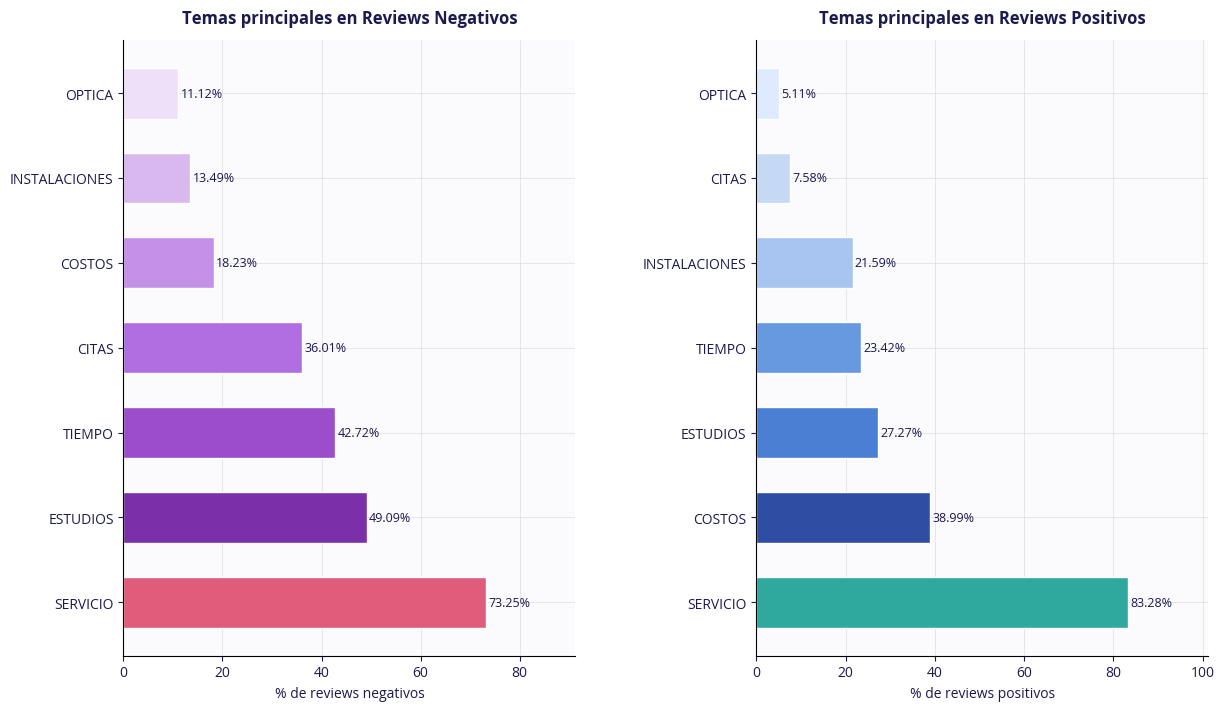

In [31]:
import matplotlib.pyplot as plt
from matplotlib import rcParams

# -- Configuración base --

# Parámetros
rcParams['font.family']       = FUENTE
rcParams['axes.facecolor']    = FONDO
rcParams['figure.facecolor']  = 'white'
rcParams['axes.spines.top']   = False
rcParams['axes.spines.right'] = False
rcParams['axes.grid']         = True
rcParams['grid.color']        = '#ddd'
rcParams['grid.linewidth']    = 0.5

# figura con dos subgráficos (1 fila, 2 columnas)
fig, axes = plt.subplots(1, 2, figsize=(14,8))
# fig.suptitle('Análisis de Reviews — Resumen General',  # titulo
#              fontsize=20, fontweight='bold', color=AZUL_OSCURO, y=1.01)
plt.subplots_adjust(hspace=0.55, wspace=0.4)  # espaciado entre sugbráficos

# -- 1. Temas negativos --
ax1 = axes[0]
bars = ax1.barh(df_resultado_neg.index, df_resultado_neg['pct'], # de barras horizontales
                color=colores_temas_neg[:len(df_resultado_neg)], edgecolor='white', height=0.6)
ax1.set_title('Temas principales en Reviews Negativos', 
              fontweight='bold', color=AZUL_OSCURO, pad=12)
ax1.set_xlabel('% de reviews negativos', color=AZUL_OSCURO) # porcentaje de las barras
for bar, val in zip(bars, df_resultado_neg['pct']):
    ax1.text(val + 0.5, bar.get_y() + bar.get_height()/2, 
             f'{val}%', va='center', fontsize=9, color=AZUL_OSCURO)
ax1.set_xlim(0, df_resultado_neg['pct'].max() + 18) # Extiende el eje X para que las etiquetas no se corten
ax1.tick_params(colors=AZUL_OSCURO)
ax1.set_axisbelow(True) # enviar lineas al fondo

# -- 2. Temas positivos --
ax2 = axes[1]
bars2 = ax2.barh(df_resultado_pos.index, df_resultado_pos['pct'],
                 color=colores_temas_pos[:len(df_resultado_pos)], edgecolor='white', height=0.6)
ax2.set_title('Temas principales en Reviews Positivos',
              fontweight='bold', color=AZUL_OSCURO, pad=12)
ax2.set_xlabel('% de reviews positivos', color=AZUL_OSCURO)
for bar, val in zip(bars2, df_resultado_pos['pct']):
    ax2.text(val + 0.5, bar.get_y() + bar.get_height()/2,
             f'{val}%', va='center', fontsize=9, color=AZUL_OSCURO)
ax2.set_xlim(0, df_resultado_pos['pct'].max() + 18)
ax2.tick_params(colors=AZUL_OSCURO)
ax2.set_axisbelow(True)

# -- Guarda gráfico --
fig.savefig('data/temas.png', dpi=150, bbox_inches='tight')
print('✅Gráfica guardada en data/temas.png')
fig.show()

## Análisis de sucursales

#### General

In [32]:
%run scripts\04_analisis_Sucursal.py

# Usa: 
# - reviews_con_sentimiento.csv

# Genera: 
# - resumen_por_sucursal.csv

PermissionError: [Errno 13] Permission denied: 'data/resumen_por_sucursal.csv'

In [33]:
import pandas as pd
import plotly.graph_objects as go

# -- Carga de datos --
resumen_sucursal = pd.read_csv('data/resumen_por_sucursal.csv', encoding='utf-8-sig')

# -- Gráfico --
# tamaño de burbujas: escala el total de reviews a un rango de 8 a 60 píxeles
# .clip(lower=8) asegura que ninguna burbuja sea más pequeña que 8px
resumen_sucursal['sizes'] = (
    resumen_sucursal['total_reviews'] * 60 / resumen_sucursal['total_reviews'].max()
).clip(lower=8)

# Líneas de cuadrante: mediana de positivos y negativos para dividir el gráfico en 4 cuadrantes
med_pos = resumen_sucursal['pct_positivos'].median()
med_neg = resumen_sucursal['pct_negativos'].median()

# Figura
fig = go.Figure()

# burbujas: Agrega un scatter plot donde cada punto es una sucursal
fig.add_trace(go.Scatter( 
    x=resumen_sucursal['pct_positivos'],               # eje X = % reviews positivos
    y=resumen_sucursal['pct_negativos'],               # eje Y = % reviews negativos
    mode='markers',                                    # solo puntos, sin líneas
    marker=dict(
        size=resumen_sucursal['sizes'],                # tamaño = volúmen de reviews
        color=resumen_sucursal['indice_sentimientos'], # color = índice calculado
        colorscale=[
            # Gradiente de color: rosa (negativo) - morado (neutro) - azul (positivo)
            [0.0,  '#fc838d'],
            [0.25, '#f8a5f4'],
            [0.38, '#f5d1ff'],
            [0.62, '#b59cf5'],
            [1.0,  '#91c4fd'],
        ],
        showscale=True,   # muestra la barra lateral de colores
        colorbar=dict(
            title=dict(
                text='Índice Sentimientos',
                font=dict(color=AZUL_OSCURO),
            ),
            tickfont=dict(color=AZUL_OSCURO),
            tickmode='array',   # marcas manuales en posiciones específicas
            tickvals=[-0.4, -0.2, 0, 0.2, 0.4, 0.6],   # posiciones
            ticktext=[                                 # etiquetas
                '-0.4 Muy negativo',
                '-0.2 Negativo',
                '0 Neutro',
                '0.2 Positivo',
                '0.4 Muy positivo',
                '0.6 Excelente',
            ],
        ),
        opacity=0.85,                        # 85% opacidad para ver superposiciones
        line=dict(color='white', width=1.5), # borde blanco de cada burbuja
    ),
    # Tooltip: nombre en negritas
    # <extra></extra> elimina el texto adicional que plotly agrega por defecto
    hovertemplate='<b>%{text}</b><extra></extra>',
    text=resumen_sucursal['Sucursal'],
))

# cuadrantes 
fig.add_hline(y=med_neg, line_dash='dash', line_color='#ccc', opacity=0.7)
fig.add_vline(x=med_pos, line_dash='dash', line_color='#ccc', opacity=0.7)

# etiquetas de cuadrantes (x,y,texto,color)
anotaciones = [
    (resumen_sucursal['pct_positivos'].max() * 0.95, resumen_sucursal['pct_negativos'].max() * 0.97, 'Mixtas', '#aaa'), # arriba derecha
    (resumen_sucursal['pct_positivos'].max() * 0.95, resumen_sucursal['pct_negativos'].min() * 1.5,'Mejores', '#aaa'), # abajo derecha
    (resumen_sucursal['pct_positivos'].min(), resumen_sucursal['pct_negativos'].max() * 0.97, 'Peores', '#aaa'), # arriba izquierda
    (resumen_sucursal['pct_positivos'].min(), resumen_sucursal['pct_negativos'].min() * 1.5,'Neutras', '#aaa'), # abajo izquierda
]

for x, y, texto, color in anotaciones:
    fig.add_annotation(x=x, y=y, text=texto, showarrow=False,font=dict(color=color, size=11))

# -- Diseño general --
fig.update_layout(
    title=dict(
        text='Mapa de Posicionamiento de Sucursales<br>'
             '<sup>% Positivos vs % Negativos | tamaño = Total comentarios | color = Índice Sentimientos</sup>',
        font=dict(size=16, color=AZUL_OSCURO),
    ),
    xaxis=dict(title='% Reviews Positivos', tickfont=dict(color=AZUL_OSCURO), gridcolor='#eeeeee'),
    yaxis=dict(title='% Reviews Negativos', tickfont=dict(color=AZUL_OSCURO), gridcolor='#eeeeee'),
    plot_bgcolor=FONDO,  # color de fondo del área del gráfico
    paper_bgcolor='white',     # color de fondo del área total
    font=dict(family=FUENTE, color=AZUL_OSCURO),
    width=850,
    height=850,
    hoverlabel=dict(
        bgcolor='white',           # fondo blanco del tooltip
        bordercolor='#c9b8f5',   # borde lila del tooltip
        font=dict(size=13, color=AZUL_OSCURO, family=FUENTE),
    ),
)

# -- Exporta y muestra --
# Guarda como HTML interactivo (se puede abrir en cualquier navegador)
fig.write_html('data/burbuja_interactiva.html')
print('✅Gráfico interactivo guardado en data/burbuja_interactiva.html')
fig.show()

✅Gráfico interactivo guardado en data/burbuja_interactiva.html


### Por tema

✅Gráfico guardado en data/temas_por_sucursal.png


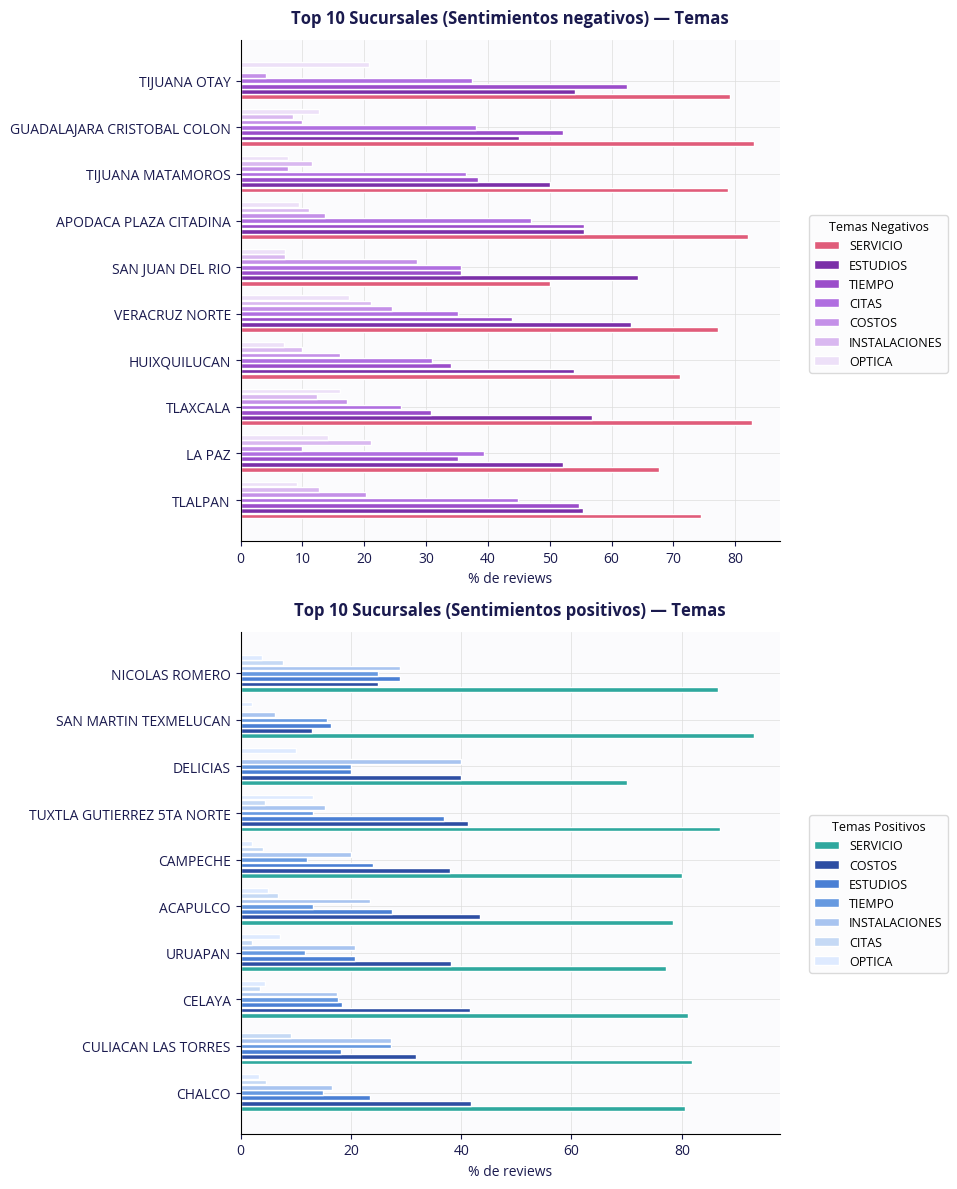

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# -- Carga datos --

df_temas = pd.read_csv('data/reviews_con_temas.csv', encoding='utf-8-sig')
resumen_sucursal = pd.read_csv('data/resumen_por_sucursal.csv', encoding='utf-8-sig')

# Agrupado por sucursal y sentimiento
temas_sucursal = df_temas.groupby(['SucursalID', 'Sucursal', 'x', 'y','sentimiento'])[temas_cols].agg('mean').reset_index()
temas_sucursal[temas_cols] = round(temas_sucursal[temas_cols] * 100, 2)

df_temas_pos = temas_sucursal[temas_sucursal['sentimiento'] == 'POS'] 
df_temas_neg = temas_sucursal[temas_sucursal['sentimiento'] == 'NEG'] 

# -- Top 10 por score --

top10_neg = resumen_sucursal.nlargest(10, 'score_negativo_prom')['SucursalID']
top10_pos = resumen_sucursal.nlargest(10, 'score_positivo_prom')['SucursalID']

df_plot_suc_pos = df_temas_pos.merge(top10_pos, on = 'SucursalID')
df_plot_suc_neg = df_temas_neg.merge(top10_neg, on = 'SucursalID')

df_plot_pos = (df_plot_suc_pos[df_resultado_pos.index.to_list()]).set_index(df_plot_suc_pos['Sucursal'])
df_plot_neg = (df_plot_suc_neg[df_resultado_neg.index.to_list()]).set_index(df_plot_suc_neg['Sucursal'])

# -- Formatos --
# se toman los formatos generales por tema

# -- Función para graficar --

def graficar_temas(df_plot, titulo, colores, ax):
    n_sucursales = len(df_plot)
    n_temas      = len(df_plot.columns)
    ancho_barra  = 0.8 / n_temas
    y            = np.arange(n_sucursales)

    for i, (tema, color) in enumerate(zip(df_plot.columns, colores)):
        offset = (i - n_temas / 2) * ancho_barra + ancho_barra / 2
        ax.barh(y + offset, df_plot[tema], height=ancho_barra * 0.9, # barras desplazadas
                label=tema, color=color, edgecolor='white')

    ax.set_yticks(y)
    ax.set_yticklabels(df_plot.index, fontsize=10, color=AZUL_OSCURO) # etiqueta del nombre de la sucursal
    ax.set_xlabel('% de reviews', color=AZUL_OSCURO)
    ax.set_title(titulo, fontweight='bold', color=AZUL_OSCURO, pad=12)
    # ax.legend(loc='center right', bbox_to_anchor=(1.01, 0.5), fontsize=7, framealpha=0.7)
    ax.legend().remove()
    ax.tick_params(colors=AZUL_OSCURO)
    ax.set_axisbelow(True) # enviar lineas al fondo
    
# -- Gráficas --
fig, axes = plt.subplots(2, 1, figsize=(8,12))
fig.patch.set_facecolor('white') # fondo exterior
plt.subplots_adjust(wspace=0.5)

graficar_temas(df_plot_neg, 'Top 10 Sucursales (Sentimientos negativos) — Temas', colores_temas_neg, axes[0])
graficar_temas(df_plot_pos, 'Top 10 Sucursales (Sentimientos positivos) — Temas', colores_temas_pos, axes[1])

# leyendas
# handles de cada gráfico
handles1, labels1 = axes[0].get_legend_handles_labels()
handles2, labels2 = axes[1].get_legend_handles_labels()

# Leyenda del gráfico superior (negativos) — posición más arriba
fig.legend(
    handles1, labels1,
    loc='center left',
    bbox_to_anchor=(1.01, 0.75),  # 75% de altura = zona del gráfico superior
    fontsize=9,
    framealpha=0.7,
    title='Temas Negativos',
    title_fontsize=9
)

# Leyenda del gráfico inferior (positivos) — posición más abajo
fig.legend(
    handles2, labels2,
    loc='center left',
    bbox_to_anchor=(1.01, 0.25),  # 25% de altura = zona del gráfico inferior
    fontsize=9,
    framealpha=0.7,
    title='Temas Positivos',
    title_fontsize=9
)

plt.tight_layout()

# -- Guarda grafico --

plt.savefig('data/temas_por_sucursal.png', dpi=150, bbox_inches='tight')
print('✅Gráfico guardado en data/temas_por_sucursal.png')
plt.show()


## Mapa

In [ ]:
import folium
import pandas as pd
from branca.colormap import LinearColormap

# -- Carga de datos --
df_reviews = pd.read_csv('data/reviews_con_temas.csv')
df_sucursales = pd.read_csv('data/resumen_por_sucursal.csv')

# -- Top 3 temas por sucursal --
# Para cada sucursal calcula los 3 temas más frecuentes,cual es su sentimiento dominante y qué % representa ese sentimiento
resultados = []

for sucursal_id, df_suc in df_reviews.groupby('SucursalID'):

    # frecuencia de cada tema
    conteos = df_suc[temas_cols].sum()

    # 3 temas con mayor frecuencia
    top3 = conteos.nlargest(3).index.tolist()

    top3_info = []
    
    # datos de estos 3 temas
    for tema in top3:

        # filtro de los reviews de cada tema
        reviews_tema = df_suc[df_suc[tema] == 1]
        total_tema = len(reviews_tema)

        # reviews positivos y negativos, por tema
        pos = (reviews_tema['sentimiento'] == 'POS').sum()
        neg = (reviews_tema['sentimiento'] == 'NEG').sum()

        # se muestra el sentimiento dominante y el % es la proporción de ese sentimiento sobre el total del tema
        if pos >= neg:
            sentimiento = 'positivo'
            pct = round(pos / total_tema * 100, 1) if total_tema > 0 else 0
        else:
            sentimiento = 'negativo'
            pct = round(neg / total_tema * 100, 1) if total_tema > 0 else 0

        # tupla con (nombre del tema, sentimiento dominante, % dominante)
        top3_info.append((tema, sentimiento, pct))

    resultados.append({'SucursalID': sucursal_id, 'top3': top3_info})

# lista de resultados a DataFrame para hacer el merge
top3_por_sucursal = pd.DataFrame(resultados)

# merge del top3 y el resumen de sucursales usando SucursalID como llave
df_sucursales = df_sucursales.merge(top3_por_sucursal, on='SucursalID', how='left')

# -- Delta vs promedio general --
# cuanto se aleja cada sucursal del promedio general de reviews positivos
# diferencia positiva = mejor que el promedio, negativo = peor que el promedio
prom_general = df_sucursales['pct_positivos'].mean()
df_sucursales['delta_positivo'] = df_sucursales['pct_positivos'] - prom_general

# -- Colorimetría: rojo (negativo) - rosa claro (neutro) - verde/azul (positivo) --
colormap = LinearColormap(
    colors=[
        '#e44242',   # -1.00 - rojo
        '#FB8492',   # -0.40 - coral
        '#F99DDB',   # -0.20 - rosa
        '#F4D0FE',   # 0 - rosa claro
        '#C0A5F7',   # 0.2 - lila
        '#93C1FC',   # 0.60 - azul
        '#63c94e',   # 1.00 - verde
    ],
    index=[-1, -0.4, -0.2, 0, 0.2, 0.6, 1],   # puntos de anclaje en escala -1 a 1
    vmin=-1, vmax=1,
    caption='Índice de Sentimientos (-1 negativo - 1 positivo)'
)

# -- Mapa base --
# fondo minimalista gris claro (CartoDB positron)
mapa = folium.Map(
    location=[24.60, -102],   # México
    zoom_start=7,
    tiles='CartoDB positron'
)

# -- Escala de radio proporcional a total_reviews --
min_rev = df_sucursales['total_reviews'].min()
max_rev = df_sucursales['total_reviews'].max()

def escalar_radio(n, r_min=8, r_max=35):
    # normalizacion min-max
    return r_min + (n - min_rev) / (max_rev - min_rev) * (r_max - r_min)

# -- círculo por sucursal --
for _, sucursal in df_sucursales.iterrows():

    # emoticón general según el índice de sentimientos de la sucursal
    emoji = '😊' if sucursal['indice_sentimientos'] >= 0 else '😞'

    # Signo del delta para mostrarlo con + o - 
    delta_signo = '+' if sucursal['delta_positivo'] >= 0 else '' 

    # -- Construcción del HTML de los temas --
    # Se inicializa vacío para no acumular temas de sucursales anteriores
    temas_html = ''
    for tema, sentimiento, pct in sucursal['top3']:
        # emoticón por sentimiento
        icono = '✅' if sentimiento == 'positivo' else '❌'
        # porcentaje: verde-positivo, rojo-negativo
        color_pct = '#2fa89e' if sentimiento == 'positivo' else '#e05c7a'
        temas_html += f'''<li>{icono} {tema.capitalize()} 
            <span style='color:{color_pct}; font-weight:bold;'>({pct}% {sentimiento})</span>
        </li>'''

    # -- Popup: se abre al hacer clic en el círculo --
    # delta verde si es positivo y rojo si es negativo
    popup_html = f'''
    <div style='font-family: Arial, sans-serif; font-size: 12px;
                color: #1a1a4e; min-width: 210px;'>
        <b style='font-size:14px;'>{sucursal['Sucursal']}</b><br>
        <hr style='margin:5px 0; border-color:#ddd;'>
        {emoji} <b>Índice Sentimientos:</b> {sucursal['indice_sentimientos']:.2f}<br>
        📊 <b>Reviews positivos:</b> {sucursal['pct_positivos']:.1f}%
           &nbsp;<span style='color:{'#2fa89e' if sucursal['delta_positivo']>=0 else '#e05c7a'};'>
           ({delta_signo}{sucursal['delta_positivo']:.1f}% vs promedio)</span><br>
        📊 <b>Reviews negativos:</b> {sucursal['pct_negativos']:.1f}%<br>
        💬 <b>Total reviews:</b> {int(sucursal['total_reviews']):,}<br>
        <hr style='margin:5px 0; border-color:#ddd;'>
        <b>Top 3 temas recurrentes:</b>
        <ul style='margin:4px 0; padding-left:16px;'>
            {temas_html}
        </ul>
    </div>
    '''

    # -- CircleMarker: el círculo en el mapa --
    folium.CircleMarker(
        location=[sucursal['x'], sucursal['y']],              # coordenadas de la sucursal
        radius=escalar_radio(sucursal['total_reviews']),      # tamaño proporcional a reviews (en pixeles)
        color='white',                                        # borde blanco para separar círculos cercanos
        weight=1.5,
        fill=True,
        fill_color=colormap(sucursal['indice_sentimientos']), # color del relleno segun indice de sentimientos
        fill_opacity=0.85,
        popup=folium.Popup(popup_html, max_width=270),        # se abre al hacer clic
        tooltip=f'{sucursal['Sucursal']} | Índice: {sucursal['indice_sentimientos']:.2f} | Reviews: {int(sucursal['total_reviews']):,}' # preview rápido al pasar el cursor
    ).add_to(mapa)

# -- Barra de color --
colormap.add_to(mapa)

# -- Colormap y guardado --
mapa.save('data/mapa_sucursales.html')
print('✅ Mapa guardado en data/mapa_sucursales.html')

✅ Mapa guardado en data/mapa_sucursales.html
